# MACHINE LEARNING-DRIVEN PREDICTIVE RESOURCE ALLOCATION SYSTEM FOR ENERGY-EFFICIENT DATA CENTRE 

- This notebook details the steps and procedure undergone in developing model that can forecast workloads in datacenters. 
- The model(s) will be instrumental part in the ML powered resource allocator.
- The model training will employ an opensource dataset found on kaggle 
- *This dataset is designed for energy-efficient computational resource allocation in cloud service management systems*. 
- *It contains* **6,345** *samples with key cloud resource metrics, including*
  -  **CPU usage**
  -  **Memory usage**
  -  **Network utilization**
  -  **Disk I/O**
  -  **Energy consumption**
  -  **Service latency.**


# DATA PREPROCCESSING
- The dataset is loaded and inspected for any missing values, outliers, or inconsistencies.
- We will check feature importance and correlation to identify which features are most relevant for predicting the target variable (energy consumption).
- The features are normalized to ensure that they are on the same scale, which is crucial for many machine learning algorithms.

In [2]:
#Loading libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Data Preprocessing Steps:
1. **Loading the Dataset**: The dataset is loaded into a pandas DataFrame for analysis
2. **Handling Missing Values**: We check for any missing values in the dataset and decide on an appropriate strategy to handle them (e.g., imputation or removal).


In [3]:
#loading dataset
data = pd.read_csv('cloud_resource_allocation_dataset.csv')
data.head()

,CPU_Usage (%),Memory_Usage (MB),Network_Usage (MBps),Disk_IO (MBps),Energy_Consumption (Watts),Service_Latency (ms),Predicted_Workload (%),Workload_Type,Task_Priority,Optimized_Resource_Allocation
0,38.708611,1672.006565,299.849111,80.730345,63.962799,221.448909,53.347812,Medium,1,2
1,90.564288,4855.632861,369.691377,141.502156,439.095473,109.940476,26.121036,Low,0,1
2,70.879455,16066.646712,262.324202,113.595918,228.348794,47.072212,54.192928,Medium,1,3
3,58.879264,9975.816106,408.852148,185.145627,168.739194,246.531890,11.554386,Low,0,1
4,19.041678,11776.947010,363.856234,6.062739,302.752831,48.275457,37.985173,Medium,1,3


In [6]:
#checking for missing values and duplicates
print(data.isnull().sum())
print("Duplicates:", data.duplicated().sum())  

CPU_Usage (%)                    0
Memory_Usage (MB)                0
Network_Usage (MBps)             0
Disk_IO (MBps)                   0
Energy_Consumption (Watts)       0
Service_Latency (ms)             0
Predicted_Workload (%)           0
Workload_Type                    0
Task_Priority                    0
Optimized_Resource_Allocation    0
dtype: int64
Duplicates: 0


Great no missing values in the dataset.   
The target variable are Predicted_Workload and  Energy_Consumption. We will check the correlation of the features with these target variables to identify which features are most relevant for our predictive model.

In [21]:
data.describe()

,CPU_Usage (%),Memory_Usage (MB),Network_Usage (MBps),Disk_IO (MBps),Energy_Consumption (Watts),Service_Latency (ms),Predicted_Workload (%),Task_Priority,Optimized_Resource_Allocation
count,6345.000000,6345.000000,6345.000000,6345.000000,6345.000000,6345.000000,6345.000000,6345.000000,6345.000000
mean,49.683017,8382.224282,257.145571,102.177142,271.986176,126.966980,52.369345,0.992750,2.652167
std,26.032643,4557.962792,141.487996,57.433787,129.227886,70.438630,27.536769,0.794018,1.156247
min,5.001047,512.838469,10.123703,1.009577,50.030374,5.001356,5.001590,0.000000,1.000000
25%,26.959577,4480.900871,134.239390,52.758394,160.241097,65.430779,28.752284,0.000000,2.000000
50%,49.745729,8307.389462,258.288764,102.731599,271.637727,127.637742,52.079056,1.000000,3.000000
75%,72.144039,12338.746984,380.007717,151.086171,383.446963,187.232105,76.493893,2.000000,3.000000
max,94.974591,16378.813114,499.963165,199.980294,499.879438,249.948396,99.997354,2.000000,5.000000


### Exploratory Data Analysis (EDA)
#### Identifying and Removing Outliers
- We will use box plots to identify outliers in the dataset.
- Outliers can skew the results of machine learning models, so we will remove any identified outliers to improve model performance.

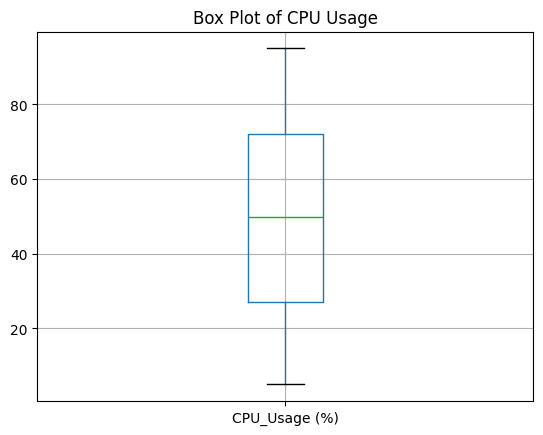

In [12]:
#id outlier in CPU_Usage
data.boxplot(column='CPU_Usage (%)')
plt.title('Box Plot of CPU Usage')
plt.show()

No outliers were identified in the column CPU_Usage, we will check for outliers in the other features as well.

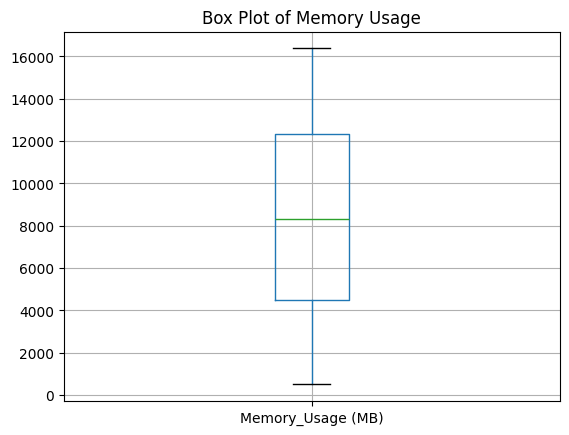

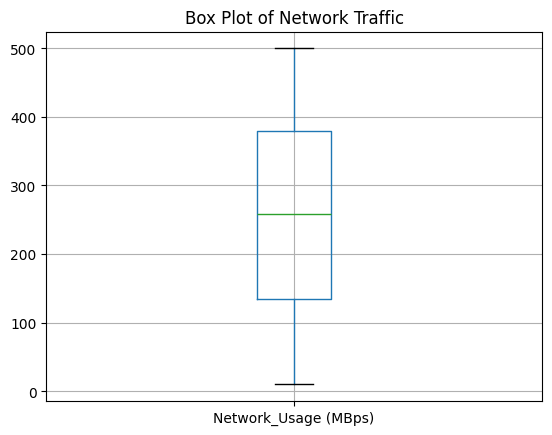

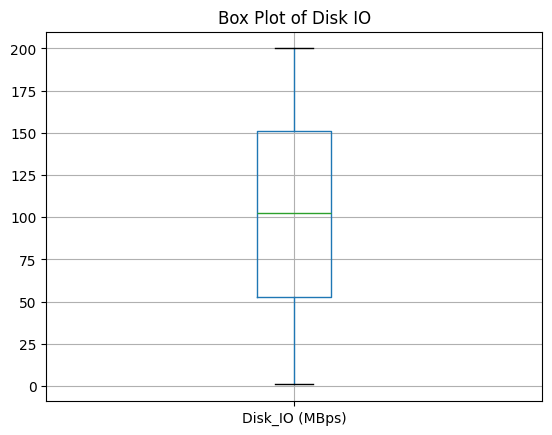

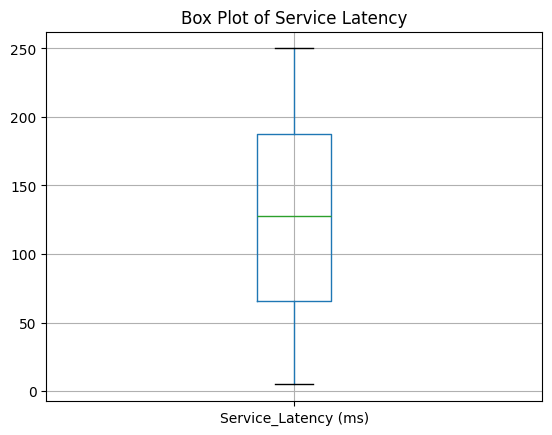

In [ ]:
#id outliers in Memory_Usage
data.boxplot(column='Memory_Usage (MB)')
plt.title('Box Plot of Memory Usage')
plt.show()

#id outliers in Network_Traffic
data.boxplot(column='Network_Usage (MBps)')
plt.title('Box Plot of Network Traffic')
plt.show()

#id outliers in Disk_IO
data.boxplot(column='Disk_IO (MBps)')
plt.title('Box Plot of Disk IO')
plt.show()

#id ouliers in service latency
data.boxplot(column='Service_Latency (ms)')
plt.title('Box Plot of Service Latency')
plt.show()

#id outliers in Task_Priority
data.boxplot(column='Task_Priority')
plt.title('Box Plot of Task Priority')
plt.show()


Task_Priority	Optimized_Resource_Allocation

From the box plots we can see that there are no outliers in the dataset, we will proceed to check the correlation of the features with the target variables Predicted_Workload and Energy_Consumption.

## FEATURE SELECTION
### Correlation Analysis
- We will compute the correlation of the features with the first target variable (predicted workload) to identify which features are most relevant for our predictive model.

In [23]:
#correlation analysis with target variable feature by featurePredicted_Workload
# CPU_Usage
correlation_cpu = data['CPU_Usage (%)'].corr(data['Predicted_Workload (%)'])
print("Correlation between CPU Usage and Predicted Workload:", correlation_cpu)
# Memory_Usage
correlation_memory = data['Memory_Usage (MB)'].corr(data['Predicted_Workload (%)'])
print("Correlation between Memory Usage and Predicted Workload:", correlation_memory)
# Network_Traffic
correlation_network = data['Network_Usage (MBps)'].corr(data['Predicted_Workload (%)'])
print("Correlation between Network Traffic and Predicted Workload:", correlation_network)
# Disk_IO
correlation_disk = data['Disk_IO (MBps)'].corr(data['Predicted_Workload (%)'])
print("Correlation between Disk IO and Predicted Workload:", correlation_disk)
# Service_Latency
correlation_latency = data['Service_Latency (ms)'].corr(data['Predicted_Workload (%)'])
print("Correlation between Service Latency and Predicted Workload:", correlation_latency)
# Task_Priority
correlation_priority = data['Task_Priority'].corr(data['Predicted_Workload (%)'])
print("Correlation between Task Priority and Predicted Workload:", correlation_priority)


Correlation between CPU Usage and Predicted Workload: 0.010812700838474494
Correlation between Memory Usage and Predicted Workload: 0.01749885080003546
Correlation between Network Traffic and Predicted Workload: 0.007397381866029689
Correlation between Disk IO and Predicted Workload: 0.0010875992847385516
Correlation between Service Latency and Predicted Workload: -0.003967167033810438
Correlation between Task Priority and Predicted Workload: 0.9424375379979065


**Correlation analysis revealed near-zero linear relationships between features and the target, consistent with independent random sampling in synthetic dataset generation. This motivates the use of non-linear models (Random Forest, Gradient Boosting) capable of detecting higher-order feature interactions.**

The absence of strong Pearson correlations suggests non-linear dependencies, which Spearman rank correlation and mutual information analysis will be used to further investigate."

In [22]:
#Spearman rank correlation
# CPU_Usage
spearman_cpu = data['CPU_Usage (%)'].corr(data['Predicted_Workload (%)'], method='spearman')
print("Spearman Correlation between CPU Usage and Predicted Workload:", spearman_cpu)
# Memory_Usage
spearman_memory = data['Memory_Usage (MB)'].corr(data['Predicted_Workload (%)'], method='spearman')
print("Spearman Correlation between Memory Usage and Predicted Workload:", spearman_memory)
# Network_Traffic
spearman_network = data['Network_Usage (MBps)'].corr(data['Predicted_Workload (%)'], method='spearman')
print("Spearman Correlation between Network Traffic and Predicted Workload:", spearman_network)
# Disk_IO
spearman_disk = data['Disk_IO (MBps)'].corr(data['Predicted_Workload (%)'], method='spearman')
print("Spearman Correlation between Disk IO and Predicted Workload:", spearman_disk)
# Service_Latency
spearman_latency = data['Service_Latency (ms)'].corr(data['Predicted_Workload (%)'], method='spearman')
print("Spearman Correlation between Service Latency and Predicted Workload:", spearman_latency)
# Task_Priority
spearman_priority = data['Task_Priority'].corr(data['Predicted_Workload (%)'], method='spearman')
print("Spearman Correlation between Task Priority and Predicted Workload:", spearman_priority)


Spearman Correlation between CPU Usage and Predicted Workload: 0.01079235853498574
Spearman Correlation between Memory Usage and Predicted Workload: 0.017454607445209835
Spearman Correlation between Network Traffic and Predicted Workload: 0.007431104482602062
Spearman Correlation between Disk IO and Predicted Workload: 0.0008468732922730954
Spearman Correlation between Service Latency and Predicted Workload: -0.003738671748478508
Spearman Correlation between Task Priority and Predicted Workload: 0.9417310392202164


### Correlation Analysis for Energy Consumption
- We will compute the correlation of the features with the second target variable (energy consumption) to identify which features are most relevant for our predictive model.

In [ ]:
#id correlation with energy consumption
# CPU_Usage
correlation_cpu_energy = data['CPU_Usage (%)'].corr(data['Energy_Consumption (Watts)'])
print("Correlation between CPU Usage and Energy Consumption:", correlation_cpu_energy)
# Memory_Usage
correlation_memory_energy = data['Memory_Usage (MB)'].corr(data['Energy_Consumption (Watts)'])
print("Correlation between Memory Usage and Energy Consumption:", correlation_memory_energy)
# Network_Traffic
correlation_network_energy = data['Network_Usage (MBps)'].corr(data['Energy_Consumption (Watts)'])
print("Correlation between Network Traffic and Energy Consumption:", correlation_network_energy)
# Disk_IO
correlation_disk_energy = data['Disk_IO (MBps)'].corr(data['Energy_Consumption (Watts)'])
print("Correlation between Disk IO and Energy Consumption:", correlation_disk_energy)
# Service_Latency
correlation_latency_energy = data['Service_Latency (ms)'].corr(data['Energy_Consumption (Watts)'])
print("Correlation between Service Latency and Energy Consumption:", correlation_latency_energy)
# Task_Priority
correlation_priority_energy = data['Task_Priority'].corr(data['Energy_Consumption (Watts)'])
print("Correlation between Task Priority and Energy Consumption:", correlation_priority_energy)


KeyError: 'Energy_Consumption (kWh)'